---
# 1. Imports and Configuration

In this section, we import all required libraries for text cleaning and
pre-processing for an RNN-based house price prediction model.

We also set global configuration such as random seeds for reproducibility.

In [ ]:
"""NLP preprocessing pipeline for RNN-based house price prediction.

This notebook section focuses on:
    • Loading the housing dataset.
    • Cleaning and normalising the description text.
    • Explicitly removing price mentions from descriptions to prevent
      target leakage.
    • Splitting the data into train/validation/test sets.
    • Tokenising and padding sequences for RNN models.
"""

from __future__ import annotations

import os
import random
import re
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ---------------------------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------------------------
drive.mount("/content/drive")

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------------
# Filepaths
# ---------------------------------------------------------------------------
RAW_PATH: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/"
    "nlp_data_raw/austinHousingData.csv"
)

PROCESSED_DIR: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed"
)
os.makedirs(PROCESSED_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Core libraries for data manipulation (pandas, NumPy), splitting (scikit-learn),
  and NLP pre-processing (TensorFlow Keras Tokenizer) have been imported.
- Random seeds are set to ensure consistent results across runs.
- The module docstring clearly documents the purpose of this notebook section.

---
# 2. Load Raw Housing Data

In this section, we load the raw Austin housing data from CSV.

Update `DATA_PATH` if your file is stored in a different folder.

In [ ]:
"""Load and validate the Austin housing raw dataset.

This section:
    • Ensures the raw dataset exists at the expected file path.
    • Loads the CSV into a pandas DataFrame.
    • Prints structural metadata (shape, columns) for verification.
"""


def load_raw_dataset(path: str) -> pd.DataFrame:
    """Load the raw Austin housing dataset from disk.

    Args:
        path: Absolute filepath to the CSV file.

    Returns:
        A pandas DataFrame containing the raw dataset.

    Raises:
        FileNotFoundError: If the CSV file does not exist at the given path.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Raw data not found at: {path}")

    df = pd.read_csv(path)

    print("[INFO] Raw dataset loaded successfully.")
    print("[INFO] Shape:", df.shape)
    print("[INFO] Columns:", df.columns.tolist())

    return df


# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------
df_raw = load_raw_dataset(RAW_PATH)

[INFO] Raw dataset loaded.
[INFO] Shape: (15171, 47)
[INFO] Columns: ['zpid', 'city', 'streetAddress', 'zipcode', 'description', 'latitude', 'longitude', 'propertyTaxRate', 'garageSpaces', 'hasAssociation', 'hasCooling', 'hasGarage', 'hasHeating', 'hasSpa', 'hasView', 'homeType', 'parkingSpaces', 'yearBuilt', 'latestPrice', 'numPriceChanges', 'latest_saledate', 'latest_salemonth', 'latest_saleyear', 'latestPriceSource', 'numOfPhotos', 'numOfAccessibilityFeatures', 'numOfAppliances', 'numOfParkingFeatures', 'numOfPatioAndPorchFeatures', 'numOfSecurityFeatures', 'numOfWaterfrontFeatures', 'numOfWindowFeatures', 'numOfCommunityFeatures', 'lotSizeSqFt', 'livingAreaSqFt', 'numOfPrimarySchools', 'numOfElementarySchools', 'numOfMiddleSchools', 'numOfHighSchools', 'avgSchoolDistance', 'avgSchoolRating', 'avgSchoolSize', 'MedianStudentsPerTeacher', 'numOfBathrooms', 'numOfBedrooms', 'numOfStories', 'homeImage']


- The dataset has been loaded successfully from the specified CSV path.
- The printed shape and column names allow you to verify that the expected
  `description` and `price` columns are present.
- If the file path is incorrect, a clear `FileNotFoundError` is raised.

---
# 3. Select Relevant Columns and Apply Guard Checks

Here, we:
- Define which columns are used for NLP (`description`) and target (`price`).
- Apply basic guard checks to ensure these columns exist.
- Drop rows with missing description or target values.
- Keep only the columns required for the NLP task.

In [ ]:
"""Subset and validate columns required for NLP preprocessing.

This section:
    • Verifies that the text and target columns exist.
    • Selects only the relevant fields (text, target, optional IDs).
    • Removes rows with missing values.
    • Renames the target column for consistency.
    • Resets row indices after filtering.
"""


def prepare_nlp_subset(
    df: pd.DataFrame,
    text_col: str = "description",
    target_col: str = "latestPrice",
) -> pd.DataFrame:
    """Extract and validate necessary columns for NLP preprocessing.

    Args:
        df: The full raw housing dataset.
        text_col: Name of the description column to be used as input text.
        target_col: Name of the target price column.

    Returns:
        A cleaned DataFrame containing:
            • Optional ID columns (if present)
            • Text column renamed unchanged
            • Target column renamed to ``price``

    Raises:
        KeyError: If required columns are missing.
    """
    # Validate required columns
    required_missing = {text_col, target_col} - set(df.columns)
    if required_missing:
        raise KeyError(
            "The following required columns are missing from the dataset: "
            f"{sorted(required_missing)}"
        )

    # Optional ID columns
    optional_id_cols: List[str] = [
        col for col in ["id", "unique_id", "listing_id"] if col in df.columns
    ]

    columns_to_keep: List[str] = optional_id_cols + [text_col, target_col]
    df_subset = df.loc[:, columns_to_keep].copy()

    # Remove rows missing text or target
    df_subset = df_subset.dropna(subset=[text_col, target_col])

    # Standardise target column name
    df_subset = df_subset.rename(
        columns={
            target_col: "price",
        }
    )

    # Reset index
    df_subset = df_subset.reset_index(drop=True)

    print("[INFO] NLP-focused dataset prepared.")
    print(f"[INFO] Shape after filtering: {df_subset.shape}")

    return df_subset


# ---------------------------------------------------------------------------
# Apply preprocessing
# ---------------------------------------------------------------------------
TEXT_COL: str = "description"
TARGET_COL: str = "price"

df_nlp = prepare_nlp_subset(
    df=df_raw,
    text_col=TEXT_COL,
    target_col="latestPrice",
)

[INFO] NLP-focused dataset prepared.
[INFO] Shape after filter: (15169, 2)


- Only the relevant `description` and `price` columns (plus any ID column,
  if present) are retained.
- Rows with missing text or missing price are removed to avoid issues during
  tokenisation or model training.
- The resulting shape confirms how many usable samples are available for NLP.

---
# 4. Box Plot of Price Distribution

Before proceeding to train/validation/test splitting, it is essential to
inspect the distribution of the target variable (`price`). A boxplot
allows us to:

- Identify extremely large or small property prices.
- Detect potential outliers that may influence model performance.
- Confirm that the price values follow a reasonable range.

We will generate a standard Matplotlib boxplot for the variable
`price` from the cleaned dataset (`df_clean`).

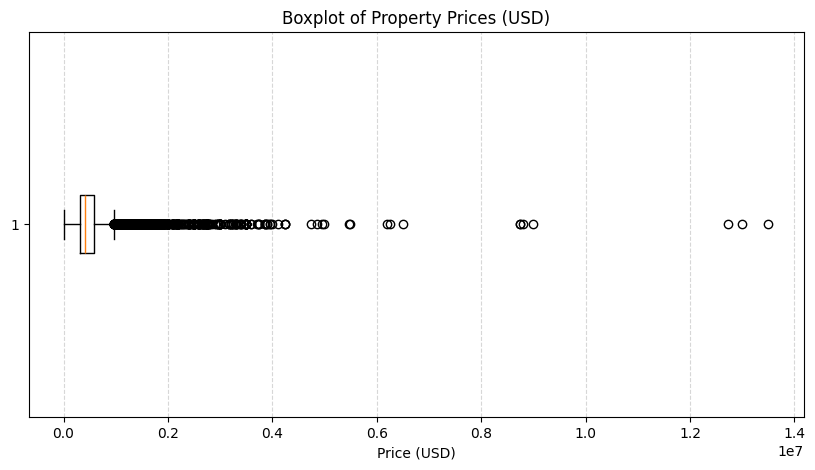

[INFO] Boxplot displayed. Min: 5,500.00, Median: 405,000.00, Max: 13,500,000.00


In [ ]:
"""Visualisation utility for plotting property price distribution.

This module provides:
    • A validated boxplot for examining property price distribution.
    • Quick summary statistics (min, median, max) for diagnostic insights.
"""


def plot_price_boxplot(
    df: pd.DataFrame,
    price_col: str = "price",
) -> None:
    """Plot a boxplot of property prices to visualise distribution and outliers.

    Args:
        df: Cleaned DataFrame containing the target price column.
        price_col: Name of the price column to plot (default: `"price"`).

    Raises:
        KeyError: If the required price column is not present in the DataFrame.
    """
    if price_col not in df.columns:
        raise KeyError(f"Column '{price_col}' not found in DataFrame.")

    plt.figure(figsize=(10, 5))
    plt.boxplot(
        df[price_col],
        vert=False,
        showfliers=True,
    )
    plt.title("Boxplot of Property Prices (USD)")
    plt.xlabel("Price (USD)")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.show()

    print(
        f"[INFO] Boxplot displayed. "
        f"Min: {df[price_col].min():,.2f}, "
        f"Median: {df[price_col].median():,.2f}, "
        f"Max: {df[price_col].max():,.2f}"
    )


# ---------------------------------------------------------------------------
# Execute visualisation
# ---------------------------------------------------------------------------
plot_price_boxplot(
    df_nlp,
    price_col="price",
)

- The boxplot reveals the overall spread of `price`.
- Extreme price values, including potential outliers, are visible.
- Summary statistics (min, median, max) were printed for quick reference.

This visual validation confirms whether price values are suitable for
subsequent train/validation/test splitting and CNN regression tasks.

---
# 5. Define Text Cleaning and Anti-Leakage Utilities

This section defines reusable functions to:
- Remove explicit price mentions from the text (to prevent target leakage).
- Perform basic normalisation (lowercasing, whitespace cleaning, etc.).
- Compose these steps into a single cleaning function for the description.

These functions are written with PEP 8, PEP 257, and Google-style docstrings.

In [ ]:
"""Leakage-aware text preprocessing utilities for housing descriptions.

This module includes:
    • Price anonymisation to prevent target leakage.
    • General text normalisation (HTML stripping, punctuation cleanup).
    • A combined high-level cleaning function.
    • A utility for capping extreme price outliers.
"""


def anonymise_price(text: str) -> str:
    """Mask or remove explicit price mentions to prevent target leakage.

    Examples of matched patterns:
        • "$350,000", "$ 350000", "$350k"
        • "USD 350,000"
        • "350k", "450K"
        • "300000 dollars", "500 bucks"

    All matched spans are replaced with a generic ``<PRICE>`` token.

    Args:
        text: Raw description text from a property listing.

    Returns:
        A cleaned string where price-like expressions are replaced by the
        token ``<PRICE>``. If the input is not a string, an empty string is
        returned.
    """
    if not isinstance(text, str):
        return ""

    patterns: List[str] = [
        r"\$\s*\d[\d,]*(?:\.\d+)?",
        r"\bUSD\s*\d[\d,]*(?:\.\d+)?",
        r"\b\d[\d,]*(?:\.\d+)?\s*(dollars|bucks)\b",
        r"\b\d{2,4}\s*[kK]\b",
    ]

    cleaned_text: str = text
    for pattern in patterns:
        cleaned_text = re.sub(
            pattern,
            " <PRICE> ",
            cleaned_text,
            flags=re.IGNORECASE,
        )

    return cleaned_text


def basic_normalise_text(text: str) -> str:
    """Perform general normalisation on free-text descriptions.

    Operations:
        • Convert text to lowercase.
        • Remove HTML tags.
        • Replace line breaks/tabs with spaces.
        • Remove unwante

- `anonymise_price` replaces currency-like patterns with a `<PRICE>` token,
  explicitly reducing the risk of target leakage from the description text.
- `basic_normalise_text` standardises casing, removes HTML tags, and
  normalises whitespace and symbols.
- `clean_description` composes both steps into a single function that will be
  applied to the dataset.

---
# 5. Apply Cleaning Pipeline to Columns

We now:
- Apply `clean_description` to every row in the `description` column.
- Store the result in a new column `description_clean`.
- Optionally review a small sample to sanity-check the cleaning.

In [ ]:
"""Apply text cleaning and price capping to the NLP dataset.

This section:
    • Creates a cleaned text column derived from the raw description.
    • Applies leakage-aware cleaning to the description text.
    • Caps extreme price outliers at 6,000,000.
    • Prints basic diagnostics for verification.
"""


def apply_text_cleaning_and_capping(
    df: pd.DataFrame,
    text_col: str,
    target_col: str,
) -> pd.DataFrame:
    """Apply description cleaning and price capping to the dataset.

    Args:
        df: Input DataFrame containing the raw text and target columns.
        text_col: Name of the raw description text column.
        target_col: Name of the target price column.

    Returns:
        A modified DataFrame with:
            • A new ``<text_col>_clean`` column containing cleaned text.
            • Price values capped at the configured upper bound.
    """
    clean_col = f"{text_col}_clean"

    df[clean_col] = df[text_col].astype(str).apply(clean_description)
    print("[INFO] Applied cleaning pipeline to description text.")
    print(df[[text_col, clean_col]].head(5))

    df = cap_price_outliers(
        df=df,
        target_col=target_col,
    )
    print("[INFO] Applied price capping at 6,000,000.")

    desc_summary = df[target_col].describe()
    print("[INFO] Price summary after capping:")
    print(desc_summary)

    return df


# ---------------------------------------------------------------------------
# Execute cleaning + capping on df_nlp
# ---------------------------------------------------------------------------
CLEAN_COL: str = f"{TEXT_COL}_clean"

df_nlp = apply_text_cleaning_and_capping(
    df=df_nlp,
    text_col=TEXT_COL,
    target_col=TARGET_COL,
)

[INFO] Applied cleaning pipeline to description text.
                                         description  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...   
2  Under construction - estimated completion in A...   
3  Absolutely darling one story home in charming ...   
4  Brimming with appeal & warm livability! Sleek ...   

                                   description_clean  
0  14424 lake victor dr, pflugerville, tx 78660 i...  
1  absolutely gorgeous 4 bedroom home with 2 full...  
2  under construction - estimated completion in a...  
3  absolutely darling one story home in charming ...  
4  brimming with appeal warm livability! sleek st...  
[INFO] Applied price capping at 6,000,000.
count    1.516900e+04
mean     5.104613e+05
std      4.110882e+05
min      5.500000e+03
25%      3.090000e+05
50%      4.050000e+05
75%      5.750000e+05
max      6.000000e+06
Name: price, dtype: float64


- The new column (e.g. `description_clean`) contains the cleaned, normalised
  text with explicit price mentions masked.
- Inspecting a few samples helps you verify that:
  - Currency values (e.g. "$350,000") are replaced with `<PRICE>`.
  - Overall text is lowercase and stripped of extraneous symbols.
- This cleaned text column will be used as the input for tokenisation.

---
# 6. Train / Validation / Test Split

To support robust model evaluation, we:
- Split the data into train, validation, and test sets (80% / 10% / 10%).
- Ensure that the splits are stratified only if necessary (here we use a simple
  random split because the target is continuous).
- The split is done **before** tokenisation to avoid any information leakage
  between sets.

In [ ]:
"""Utilities for splitting the NLP dataset into train/val/test subsets.

This section provides:
    • A robust two-stage splitting mechanism.
    • Support for arbitrary validation/test proportions.
    • Reproducible splits for NLP training pipelines.
"""


def split_train_val_test(
    df: pd.DataFrame,
    text_col: str,
    target_col: str,
    test_size: float = 0.1,
    val_size: float = 0.1,
    random_state: int = SEED,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:
    """Split the dataset into train, validation, and test sets.

    The split occurs in two logical phases:
        1. Split into ``train`` and ``temp`` (validation + test).
        2. Split ``temp`` into validation and test sets based on their
           relative proportions.

    Args:
        df: Full dataset containing text and target columns.
        text_col: Name of the cleaned text column to use as input.
        target_col: Name of the target variable column (e.g., `"price"`).
        test_size: Fraction of the dataset to allocate to the test set.
        val_size: Fraction of the dataset to allocate to the validation set.
        random_state: Seed for deterministic splitting.

    Returns:
        A tuple in the order:
            (X_train, X_val, X_test, y_train, y_val, y_test)

    Raises:
        ValueError: If ``val_size + test_size`` ≥ 1.0.
    """
    if val_size + test_size >= 1.0:
        raise ValueError("val_size + test_size must be less than 1.0.")

    X = df[text_col]
    y = df[target_col]

    # First split: train vs temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(val_size + test_size),
        random_state=random_state,
        shuffle=True,
    )

    # Fraction of temp allocated to test
    test_ratio_temp = test_size / (val_size + test_size)

    # Second split: temp → val & test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=test_ratio_temp,
        random_state=random_state,
        shuffle=True,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# ---------------------------------------------------------------------------
# Execute final split
# ---------------------------------------------------------------------------
X_train_text, X_val_text, X_test_text, y_train, y_val, y_test = (
    split_train_val_test(
        df=df_nlp,
        text_col=CLEAN_COL,
        target_col=TARGET_COL,
        test_size=0.1,
        val_size=0.1,
        random_state=SEED,
    )
)

print("[INFO] Train size:", len(X_train_text))
print("[INFO] Val size:", len(X_val_text))
print("[INFO] Test size:", len(X_test_text))

[INFO] Train size: 12135
[INFO] Val size: 1517
[INFO] Test size: 1517


- The dataset has been split into three disjoint sets:
  - Training: for fitting the RNN model.
  - Validation: for hyperparameter tuning and early stopping.
  - Test: for final unbiased performance evaluation.
- The split is performed on **cleaned text** and target, but tokenisation is
  still to be done, ensuring no cross-contamination of vocabulary statistics.

---
# 7. Tokenisation and Sequence Preparation for RNN

In this section, we:
- Fit a `Tokenizer` **only on the training text** to prevent leakage.
- Convert train/validation/test text into integer sequences.
- Determine a reasonable maximum sequence length based on the training set.
- Pad all sequences to a fixed length for RNN input compatibility.

In [ ]:
"""Tokenisation and sequence preparation utilities for NLP regression.

This section:
    • Builds and fits a Keras Tokenizer on training texts.
    • Computes a robust maximum sequence length using a quantile.
    • Converts texts into padded integer sequences for RNN models.
"""


def build_tokeniser(
    texts: pd.Series,
    num_words: int = 20_000,
    oov_token: str = "<OOV>",
) -> Tokenizer:
    """Create and fit a Keras Tokenizer on training texts.

    Args:
        texts: Series of cleaned training texts.
        num_words: Maximum vocabulary size. Tokens beyond this rank
            will be treated as out-of-vocabulary.
        oov_token: Token used to represent words outside the vocabulary.

    Returns:
        A fitted Keras Tokenizer instance.
    """
    tokeniser = Tokenizer(
        num_words=num_words,
        oov_token=oov_token,
    )
    tokeniser.fit_on_texts(texts.tolist())
    return tokeniser


def compute_max_length(
    sequences: List[List[int]],
    quantile: float = 0.95,
) -> int:
    """Compute maximum sequence length using a specified quantile.

    This approach avoids overly long sequences driven by a few outliers while
    still capturing the majority of the text length distribution.

    Args:
        sequences: List of tokenised sequences (lists of integer token IDs).
        quantile: Quantile used to determine the max length (0 < quantile ≤ 1).

    Returns:
        An integer maximum length value used for padding.

    Raises:
        ValueError: If ``quantile`` is not in the interval (0, 1].
    """
    if not 0 < quantile <= 1:
        raise ValueError("quantile must be in the range (0, 1].")

    lengths = [len(seq) for seq in sequences]
    max_length = int(np.quantile(lengths, quantile))
    return max_length


def tokenise_and_pad(
    tokeniser: Tokenizer,
    X_train_text: pd.Series,
    X_val_text: pd.Series,
    X_test_text: pd.Series,
    max_length: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert text data into padded integer sequences.

    Args:
        tokeniser: Fitted Keras Tokenizer instance.
        X_train_text: Training text series.
        X_val_text: Validation text series.
        X_test_text: Test text series.
        max_length: Maximum sequence length used for padding and truncation.

    Returns:
        A tuple of NumPy arrays:
            (X_train_seq, X_val_seq, X_test_seq)
    """
    train_seq = tokeniser.texts_to_sequences(X_train_text.tolist())
    val_seq = tokeniser.texts_to_sequences(X_val_text.tolist())
    test_seq = tokeniser.texts_to_sequences(X_test_text.tolist())

    X_train_seq = pad_sequences(
        train_seq,
        maxlen=max_length,
        padding="post",
        truncating="post",
    )
    X_val_seq = pad_sequences(
        val_seq,
        maxlen=max_length,
        padding="post",
        truncating="post",
    )
    X_test_seq = pad_sequences(
        test_seq,
        maxlen=max_length,
        padding="post",
        truncating="post",
    )

    return X_train_seq, X_val_seq, X_test_seq


# ---------------------------------------------------------------------------
# Execute tokenisation pipeline
# ---------------------------------------------------------------------------
tokeniser: Tokenizer = build_tokeniser(
    texts=X_train_text,
    num_words=20_000,
)

train_sequences: List[List[int]] = tokeniser.texts_to_sequences(
    X_train_text.tolist()
)

max_seq_length: int = compute_max_length(
    sequences=train_sequences,
    quantile=0.95,
)

X_train_seq, X_val_seq, X_test_seq = tokenise_and_pad(
    tokeniser=tokeniser,
    X_train_text=X_train_text,
    X_val_text=X_val_text,
    X_test_text=X_test_text,
    max_length=max_seq_length,
)

y_train_array = np.asarray(y_train, dtype="float32")
y_val_array = np.asarray(y_val, dtype="float32")
y_test_array = np.asarray(y_test, dtype="float32")

print("[INFO] Tokeniser vocabulary size:", len(tokeniser.word_index))
print("[INFO] Max sequence length (95th percentile):", max_seq_length)
print("[INFO] X_train_seq shape:", X_train_seq.shape)
print("[INFO] X_val_seq shape:", X_val_seq.shape)
print("[INFO] X_test_seq shape:", X_test_seq.shape)
print("[INFO] y_train_array shape:", y_train_array.shape)
print("[INFO] y_val_array shape:", y_val_array.shape)
print("[INFO] y_test_array shape:", y_test_array.shape)

[INFO] Tokeniser vocabulary size: 17275
[INFO] Max sequence length (95th percentile): 154
[INFO] X_train_seq shape: (12135, 154)
[INFO] X_val_seq shape: (1517, 154)
[INFO] X_test_seq shape: (1517, 154)


- The `Tokenizer` is fitted **only** on the training texts, ensuring that
  validation and test sets do not influence the learned vocabulary.
- The maximum sequence length is derived from the 95th percentile of training
  sequence lengths, balancing coverage and computational efficiency.
- All text data is now converted into padded integer sequences (`X_*_seq`),
  and targets are stored as float arrays (`y_*_array`).
- The data is now ready to be fed into an RNN-based regression model
  (e.g. LSTM, GRU) without leaking explicit price information from the text.

---
# 8. Export to Processed Directory
Save cleaned dataset + tokenised arrays into Google Drive


In [ ]:
"""Export processed NLP datasets and arrays to the processed directory.

This module:
    • Saves the cleaned text DataFrame.
    • Persists padded sequence arrays (train/val/test).
    • Persists target arrays (train/val/test).
    • Ensures the processed directory exists before writing outputs.
"""


# Ensure the processed directory exists
os.makedirs(PROCESSED_DIR, exist_ok=True)


def export_nlp_artifacts(
    df: pd.DataFrame,
    processed_dir: str,
    X_train_seq: np.ndarray,
    X_val_seq: np.ndarray,
    X_test_seq: np.ndarray,
    y_train_array: np.ndarray,
    y_val_array: np.ndarray,
    y_test_array: np.ndarray,
) -> None:
    """Save cleaned text DataFrame and tokenised arrays to disk.

    Args:
        df: The NLP DataFrame containing raw + cleaned text columns.
        processed_dir: Directory path where all exported artefacts will be stored.
        X_train_seq: Padded training sequences (NumPy array).
        X_val_seq: Padded validation sequences (NumPy array).
        X_test_seq: Padded test sequences (NumPy array).
        y_train_array: Training target values.
        y_val_array: Validation target values.
        y_test_array: Test target values.

    Returns:
        None. Writes artefacts directly to disk.
    """
    # Export cleaned text DataFrame
    df_path = os.path.join(processed_dir, "nlp_text_cleaned.csv")
    df.to_csv(df_path, index=False)

    # Export sequence arrays
    np.save(os.path.join(processed_dir, "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(processed_dir, "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(processed_dir, "X_test_seq.npy"), X_test_seq)

    # Export target arrays
    np.save(os.path.join(processed_dir, "y_train.npy"), y_train_array)
    np.save(os.path.join(processed_dir, "y_val.npy"), y_val_array)
    np.save(os.path.join(processed_dir, "y_test.npy"), y_test_array)

    print("[INFO] Exported cleaned text and NumPy arrays to:")
    print(f"       {processed_dir}")


# ---------------------------------------------------------------------------
# Execute export
# ---------------------------------------------------------------------------
export_nlp_artifacts(
    df=df_nlp,
    processed_dir=PROCESSED_DIR,
    X_train_seq=X_train_seq,
    X_val_seq=X_val_seq,
    X_test_seq=X_test_seq,
    y_train_array=y_train_array,
    y_val_array=y_val_array,
    y_test_array=y_test_array,
)

[INFO] Exported cleaned text and NumPy arrays to:
       /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/


- Cleaned text + fully preprocessed sequences are now stored safely.
- Ready for RNN model development (LSTM/GRU/Bidirectional etc.).

# 9. Summary

At this stage, the pipeline has:
- Loaded and filtered the Austin housing dataset.
- Explicitly removed or masked price mentions from descriptions to prevent
  target leakage into the text features.
- Normalised and cleaned the description text.
- Performed an 80/10/10 train/validation/test split.
- Converted text into tokenised, padded sequences suitable for RNNs.

You can now proceed to define and train your RNN regression model using:
- `X_train_seq`, `y_train_array` for training.
- `X_val_seq`, `y_val_array` for validation.
- `X_test_seq`, `y_test_array` for final evaluation.

This end-to-end pre-processing flow aligns with MLOps best practices and
reduces the risk of subtle data leakage from the textual descriptions.